In [ ]:
# Download the zip file directly from Microsoft
!wget https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

# Unzip the file
!unzip -q kagglecatsanddogs_5340.zip

# Verify the folder exists
import os
print(os.listdir('PetImages'))
# Should output: ['Cat', 'Dog']

--2026-03-05 08:33:30--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 72.247.96.197, 2600:1406:5400:2ae::317f, 2600:1406:5400:2ac::317f
Connecting to download.microsoft.com (download.microsoft.com)|72.247.96.197|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip.1’

kagglecatsanddogs_5 100%[===================>] 786.67M   172MB/s    in 8.8s    

2026-03-05 08:33:39 (89.0 MB/s) - ‘kagglecatsanddogs_5340.zip.1’ saved [824887076/824887076]

replace PetImages/Cat/0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace PetImages/Cat/1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
['Dog', 'Cat']


In [ ]:
import os

base_dir = '/content/PetImages'
categories = ['Cat', 'Dog']

def count_files(directory, cats_dogs):
    counts = {}
    for cat in cats_dogs:
        path = os.path.join(directory, cat)
        if os.path.exists(path):
            # Counting all files including hidden/junk ones
            counts[cat] = len(os.listdir(path))
        else:
            counts[cat] = 0
    return counts

# 1. Capture counts BEFORE cleaning
before_counts = count_files(base_dir, categories)

# --- YOUR CLEANING LOGIC START ---
for root, dirs, files in os.walk(base_dir):
    for file in files:
        file_path = os.path.join(root, file)
        # Combine your logic: extension check OR zero-byte check
        if not file.lower().endswith(('.jpg', '.jpeg', '.png')) or os.path.getsize(file_path) == 0:
            os.remove(file_path)
# --- YOUR CLEANING LOGIC END ---

# 2. Capture counts AFTER cleaning
after_counts = count_files(base_dir, categories)

# 3. Print the Summary Table
print(f"{'Category':<10} | {'Before':<10} | {'After':<10} | {'Removed':<10}")
print("-" * 45)
for cat in categories:
    removed = before_counts[cat] - after_counts[cat]
    print(f"{cat:<10} | {before_counts[cat]:<10} | {after_counts[cat]:<10} | {removed:<10}")

total_removed = sum(before_counts.values()) - sum(after_counts.values())
print("-" * 45)
print(f"Total files purged: {total_removed}")

Category   | Before     | After      | Removed   
---------------------------------------------
Cat        | 12501      | 12499      | 2         
Dog        | 12501      | 12499      | 2         
---------------------------------------------
Total files purged: 4


In [ ]:
import os
!find /content -type d -name "Cat"
!find /content -type d -name "Dog"
print(os.listdir('/content'))
# Path to the folders
base_dir = '/content/PetImages'


for root, dirs, files in os.walk(base_dir):
    for file in files:
        # Delete anything that isn't a standard image
        if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
            file_path = os.path.join(root, file)
            os.remove(file_path)
            print(f"Removed: {file_path}")

# Also check for zero-byte (empty) files
for root, dirs, files in os.walk(base_dir):
    for file in files:
        file_path = os.path.join(root, file)
        if os.path.getsize(file_path) == 0:
            os.remove(file_path)
            print(f"Removed empty file: {file_path}")

/content/PetImages/Cat
/content/PetImages/Dog
['.config', 'readme[1].txt', 'CDLA-Permissive-2.0.pdf', 'PetImages', 'kagglecatsanddogs_5340.zip', 'sample_data']
Removed: /content/PetImages/Dog/Thumbs.db
Removed: /content/PetImages/Cat/Thumbs.db
Removed empty file: /content/PetImages/Dog/11702.jpg
Removed empty file: /content/PetImages/Cat/666.jpg


In [ ]:
import os

base_dir = '/content/PetImages'
categories = ['Cat', 'Dog']

for category in categories:
    folder_path = os.path.join(base_dir, category)

    # List all files and filter out hidden files (like .DS_Store)
    files = [f for f in os.listdir(folder_path) if not f.startswith('.')]

    print(f"Total {category} images: {len(files)}")

Total Cat images: 12499
Total Dog images: 12499


In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
import os
import matplotlib.image as mpimg
from PIL import Image
from zipfile import ZipFile

# data_path = 'dog-vs-cat.zip'
# with ZipFile(data_path, 'r') as zip:
#     zip.extractall()
#     print('Dataset extracted successfully')

# #Resizing and Normalization (rescale) handled here


In [ ]:
import os
import tensorflow as tf
from PIL import Image

base_dir = '/content/PetImages'
folders = ['Cat', 'Dog']
removed_count = 0

for folder in folders:
    folder_path = os.path.join(base_dir, folder)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            # 1. Remove non-images and Thumbs.db
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                os.remove(fpath)
                removed_count += 1
                continue

            # 2. Check for empty files
            if os.path.getsize(fpath) == 0:
                os.remove(fpath)
                removed_count += 1
                continue

            # 3. Deep check: Try to decode the image header with PIL
            # This catches "truncated" or "corrupt" JPEGs
            img = Image.open(fpath)
            img.verify()

        except (IOError, SyntaxError, Image.UnidentifiedImageError) as e:
            os.remove(fpath)
            removed_count += 1
            print(f"Removed corrupt image: {fname}")

print(f"✅ Cleanup complete! Total files removed: {removed_count}")

✅ Cleanup complete! Total files removed: 0


In [ ]:
class SafeImageDataGenerator(ImageDataGenerator):
    def flow_from_directory(self, *args, **kwargs):
        generator = super().flow_from_directory(*args, **kwargs)
        while True:
            try:
                yield next(generator)
            except (IOError, SyntaxError, Image.UnidentifiedImageError):
                # If a bad image is hit, the generator just grabs the next batch
                continue

datagen = SafeImageDataGenerator(rescale=1./255,
                rotation_range=40,      # Rotate images randomly up to 40 degrees
                width_shift_range=0.2,  # Translate horizontally
                height_shift_range=0.2, # Translate vertically
                shear_range=0.2,        # Randomly distort along an axis
                zoom_range=0.2,         # Randomly zoom in/out
                horizontal_flip=True,   # Flip images left-to-right
                fill_mode='nearest',    # How to fill pixels lost during rotation/shift
                validation_split=0.2
              )
base_dir = '/content/PetImages'
temp_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150), # Resizing
    batch_size=64,
    class_mode='binary',
      # Ensure correct class labels
    subset='training'       # 80% Training
)
temp_train = temp_datagen.flow_from_directory(base_dir, subset='training')
temp_val = temp_datagen.flow_from_directory(base_dir, subset='validation')
train_samples = temp_train.samples
val_samples = temp_val.samples
batch_size = 64

train_steps = train_samples // batch_size
val_steps = val_samples //batch_size

val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary',
      # Ensure correct class labels
    subset='validation'     # 20% Validation
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
model = tf.keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'), # Added extra layer
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),  # Increased dropout since we have many neurons

    layers.Dense(256, activation='relu'), # Tapered down the units
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])



In [ ]:

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,   # Multiply LR by 0.2
    patience=3,    # Wait 3 epochs before dropping
    min_lr=0.00001
)
history = model.fit(train_generator,
                    steps_per_epoch = train_steps,
                    epochs=25,
                    validation_data=val_generator,
                    validation_steps = val_steps,
                    callbacks=[reduce_lr] # Include the callback here
                    )

Epoch 1/25
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.5712 - loss: 0.6957Found 4998 images belonging to 2 classes.
312/312 ━━━━━━━━━━━━━━━━━━━━ 173s 555ms/step - accuracy: 0.5712 - loss: 0.6957 - val_accuracy: 0.5970 - val_loss: 0.6528 - learning_rate: 0.0010
Epoch 2/25
312/312 ━━━━━━━━━━━━━━━━━━━━ 168s 541ms/step - accuracy: 0.6328 - loss: 0.6369 - val_accuracy: 0.6374 - val_loss: 0.6271 - learning_rate: 0.0010
Epoch 3/25
312/312 ━━━━━━━━━━━━━━━━━━━━ 171s 550ms/step - accuracy: 0.6707 - loss: 0.6057 - val_accuracy: 0.6763 - val_loss: 0.6059 - learning_rate: 0.0010
Epoch 4/25
312/312 ━━━━━━━━━━━━━━━━━━━━ 173s 557ms/step - accuracy: 0.6829 - loss: 0.5847 - val_accuracy: 0.6907 - val_loss: 0.5872 - learning_rate: 0.0010
Epoch 5/25
312/312 ━━━━━━━━━━━━━━━━━━━━ 165s 529ms/step - accuracy: 0.7018 - loss: 0.5657 - val_accuracy: 0.6954 - val_loss: 0.5950 - learning_rate: 0.0010
Epoch 6/25
312/312 ━━━━━━━━━━━━━━━━━━━━ 165s 532ms/step - accuracy: 0.7395 - loss: 0.5323 - val_accura

In [ ]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.show()

NameError: name 'pd' is not defined

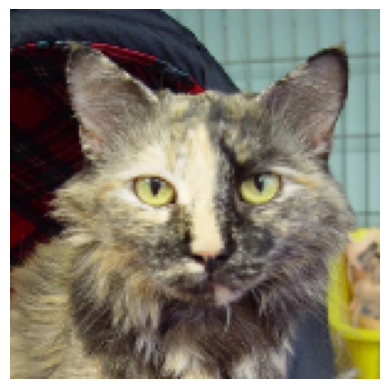

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: CAT 🐱 (Confidence: 100.00%)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_image(image_path):
    # 1. Load the image and display it
    img = load_img(image_path, target_size=(150, 150))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # 2. Convert to array and Normalize (Match the 1./255 training)
    img_array = img_to_array(img)
    img_array = img_array / 255.0

    # 3. Expand dimensions: (150, 150, 3) -> (1, 150, 150, 3)
    # The model expects a batch of images, even if it's just one.
    img_input = np.expand_dims(img_array, axis=0)

    # 4. Get the prediction
    prediction = model.predict(img_input)

    # 5. Interpret the result (Sigmoid output)
    if prediction[0] > 0.5:
        print(f"Prediction: DOG 🐶 (Confidence: {prediction[0][0]:.2%})")
    else:
        print(f"Prediction: CAT 🐱 (Confidence: {1 - prediction[0][0]:.2%})")

# Example usage:
predict_image('/content/PetImages/Cat/10.jpg')

In [ ]:
import os
folder_path ='/content/PetImages/Dog'
dog_files = os.listdir(folder_path)
lst = dog_files[50:55]
for i in lst:
  full_path = os.path.join(folder_path, i)
  print(f"Testing image: {i}")
  predict_image(full_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/PetImages/Dog'